<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/SARSA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SARSA - SMART GAME PLAYER
Training Completed!
Episodes        : 1500
Learning Rate   : 0.1
Discount Factor : 0.9
Final Epsilon   : 0.01
Success Rate    : 87.47 %
Average Reward  : 45.41
Average Steps   : 20.52

BEST LEARNED PATH
1 -> (0, 0)
2 -> (0, 1)
3 -> (0, 2)
4 -> (0, 3)
5 -> (0, 4)
6 -> (0, 5)
7 -> (0, 6)
8 -> (0, 7)
9 -> (1, 7)
10 -> (2, 7)
11 -> (3, 7)
12 -> (4, 7)
13 -> (5, 7)
14 -> (6, 7)
15 -> (7, 7)

Path Length: 15
Result: GOAL REACHED!


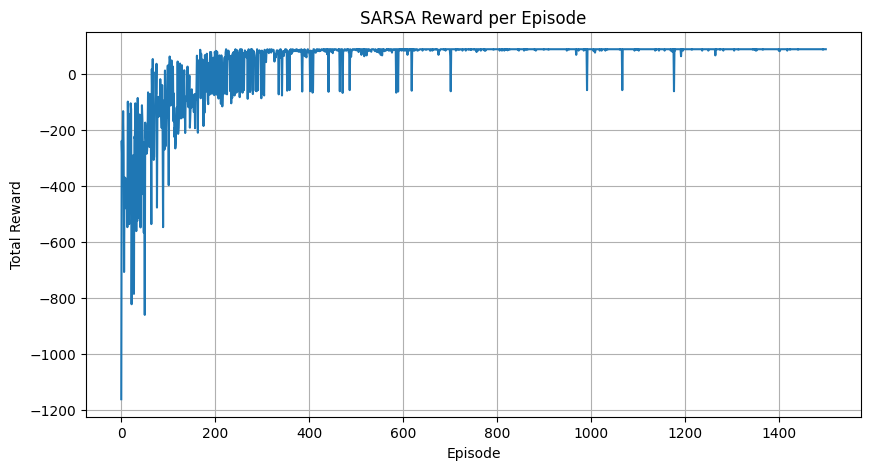

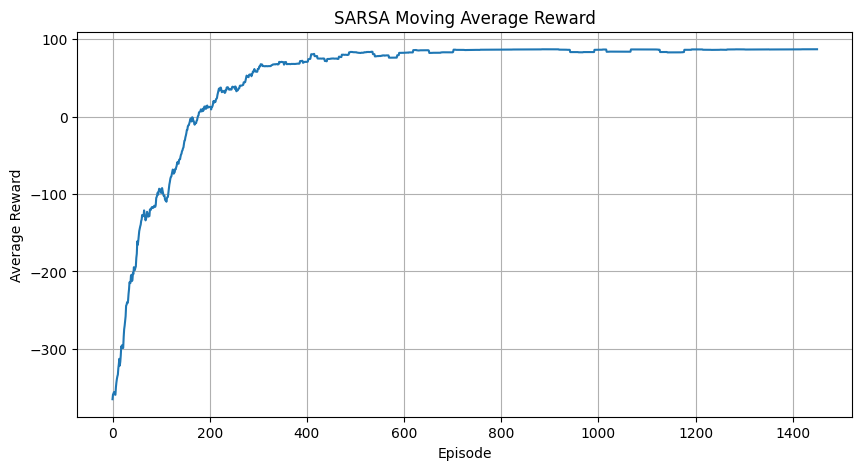

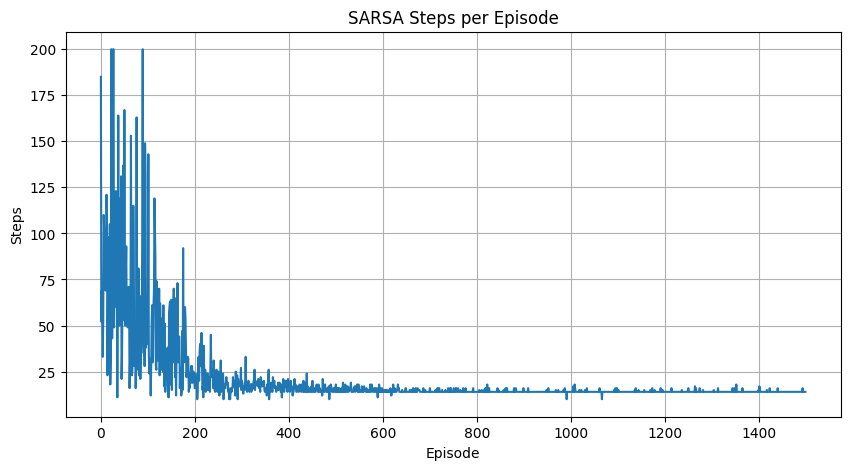

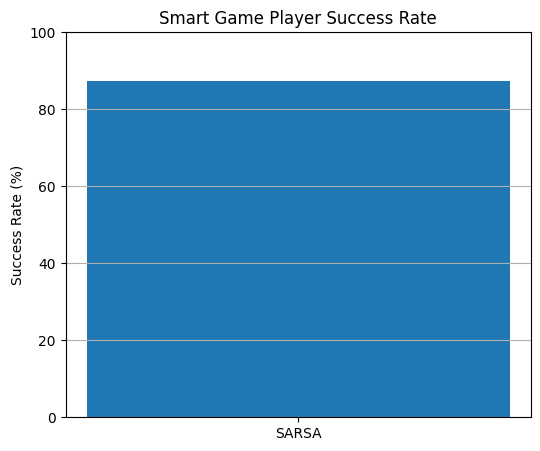

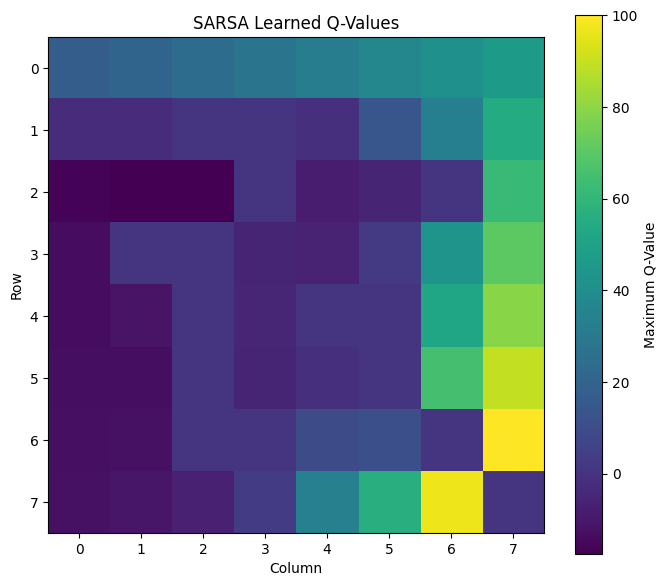

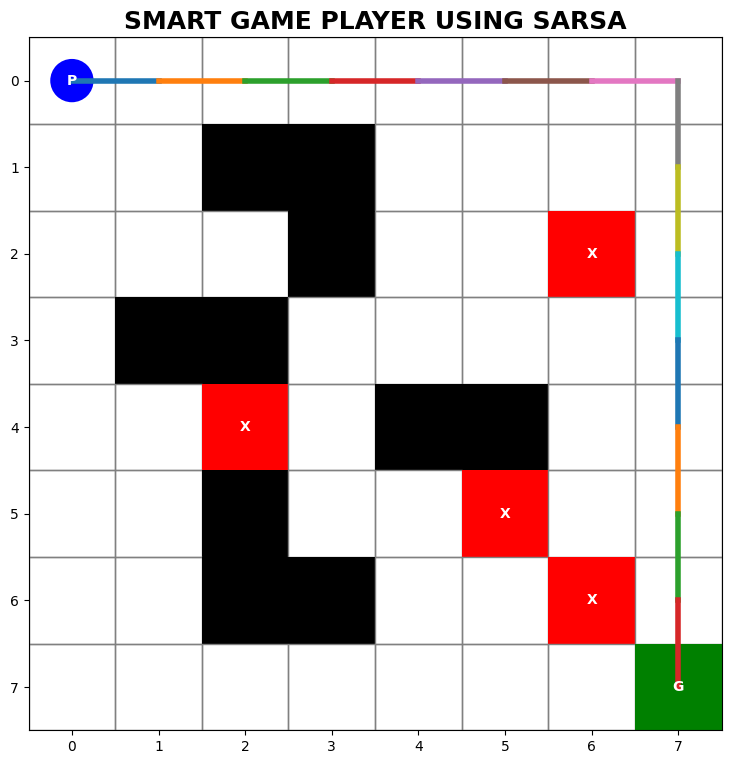


FINAL RESULT
Algorithm       : SARSA
Successful Games: 1312
Success Rate    : 87.47 %
Best Path Length: 15
Final Reward    : 87


In [3]:
# ============================================================
# SARSA - SMART GAME PLAYER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# ============================================================
# 1. GAME BOARD
# ============================================================

ROWS = 8
COLS = 8

# 0 = Empty
# 1 = Wall / Obstacle
# 2 = Trap
# 3 = Goal

grid = np.zeros((ROWS, COLS))

# Obstacles
obstacles = [
    (1, 2), (1, 3),
    (2, 3),
    (3, 1), (3, 2),
    (4, 4), (4, 5),
    (5, 2),
    (6, 2), (6, 3)
]

for r, c in obstacles:
    grid[r, c] = 1

# Traps
traps = [
    (2, 6),
    (4, 2),
    (5, 5),
    (6, 6)
]

for r, c in traps:
    grid[r, c] = 2

# Start and Goal
start = (0, 0)
goal = (7, 7)

grid[goal] = 3


# ============================================================
# 2. ACTIONS
# ============================================================

# 0 = Up
# 1 = Down
# 2 = Left
# 3 = Right

actions = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]

action_names = [
    "UP",
    "DOWN",
    "LEFT",
    "RIGHT"
]

num_states = ROWS * COLS
num_actions = 4


# ============================================================
# 3. Q-TABLE
# ============================================================

q_table = np.zeros(
    (num_states, num_actions)
)


# ============================================================
# 4. PARAMETERS
# ============================================================

episodes = 1500

learning_rate = 0.1
discount_factor = 0.9

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01


# ============================================================
# 5. STATE NUMBER
# ============================================================

def get_state(position):

    row, col = position

    return row * COLS + col


# ============================================================
# 6. ENVIRONMENT
# ============================================================

def move_player(position, action):

    row, col = position

    dr, dc = actions[action]

    new_row = row + dr
    new_col = col + dc

    # Outside board
    if (
        new_row < 0
        or new_row >= ROWS
        or new_col < 0
        or new_col >= COLS
    ):
        return position, -5, False

    # Obstacle
    if grid[new_row, new_col] == 1:
        return position, -20, False

    new_position = (new_row, new_col)

    # Goal
    if new_position == goal:
        return new_position, 100, True

    # Trap
    if grid[new_row, new_col] == 2:
        return new_position, -50, True

    # Normal movement
    return new_position, -1, False


# ============================================================
# 7. EPSILON-GREEDY ACTION
# ============================================================

def choose_action(state, epsilon_value):

    if random.random() < epsilon_value:

        return random.randint(
            0,
            num_actions - 1
        )

    return np.argmax(q_table[state])


# ============================================================
# 8. SARSA TRAINING
# ============================================================

episode_rewards = []
episode_steps = []
successful_episodes = 0

for episode in range(episodes):

    position = start

    state = get_state(position)

    # First action
    action = choose_action(
        state,
        epsilon
    )

    total_reward = 0
    steps = 0
    reached_goal = False

    for step in range(200):

        # ----------------------------------------------------
        # Take Action
        # ----------------------------------------------------

        next_position, reward, done = move_player(
            position,
            action
        )

        next_state = get_state(
            next_position
        )

        # ----------------------------------------------------
        # Choose NEXT Action
        # ----------------------------------------------------

        next_action = choose_action(
            next_state,
            epsilon
        )

        # ----------------------------------------------------
        # SARSA UPDATE
        # ----------------------------------------------------

        if done:

            target = reward

        else:

            target = (
                reward
                + discount_factor *
                q_table[next_state, next_action]
            )

        q_table[state, action] += (
            learning_rate *
            (
                target
                - q_table[state, action]
            )
        )

        total_reward += reward

        steps += 1

        position = next_position

        state = next_state

        action = next_action

        # ----------------------------------------------------
        # Goal / Trap
        # ----------------------------------------------------

        if done:

            if position == goal:
                successful_episodes += 1
                reached_goal = True

            break

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    # --------------------------------------------------------
    # Epsilon Decay
    # --------------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )


# ============================================================
# 9. TRAINING RESULTS
# ============================================================

success_rate = (
    successful_episodes
    / episodes
) * 100

print("=" * 60)
print("SARSA - SMART GAME PLAYER")
print("=" * 60)

print("Training Completed!")

print("Episodes        :", episodes)

print("Learning Rate   :", learning_rate)

print("Discount Factor :", discount_factor)

print("Final Epsilon   :", round(epsilon, 4))

print(
    "Success Rate    :",
    round(success_rate, 2),
    "%"
)

print(
    "Average Reward  :",
    round(np.mean(episode_rewards), 2)
)

print(
    "Average Steps   :",
    round(np.mean(episode_steps), 2)
)


# ============================================================
# 10. FIND BEST PATH
# ============================================================

position = start

path = [position]

for step in range(100):

    state = get_state(position)

    action = np.argmax(q_table[state])

    next_position, reward, done = move_player(
        position,
        action
    )

    # Stop if player cannot move
    if next_position == position:
        break

    position = next_position

    path.append(position)

    if done:
        break


# ============================================================
# 11. PRINT BEST PATH
# ============================================================

print("\n" + "=" * 60)
print("BEST LEARNED PATH")
print("=" * 60)

for i, position in enumerate(path):

    print(
        i + 1,
        "->",
        position
    )

print("\nPath Length:", len(path))

if path[-1] == goal:
    print("Result: GOAL REACHED!")

else:
    print("Result: Goal not reached.")


# ============================================================
# GRAPH 1 - REWARD
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards
)

plt.title(
    "SARSA Reward per Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.grid()

plt.show()


# ============================================================
# GRAPH 2 - MOVING AVERAGE
# ============================================================

window = 50

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    moving_average
)

plt.title(
    "SARSA Moving Average Reward"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Average Reward"
)

plt.grid()

plt.show()


# ============================================================
# GRAPH 3 - STEPS PER EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    episode_steps
)

plt.title(
    "SARSA Steps per Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Steps"
)

plt.grid()

plt.show()


# ============================================================
# GRAPH 4 - SUCCESS RATE
# ============================================================

plt.figure(figsize=(6, 5))

plt.bar(
    ["SARSA"],
    [success_rate]
)

plt.ylim(
    0,
    100
)

plt.ylabel(
    "Success Rate (%)"
)

plt.title(
    "Smart Game Player Success Rate"
)

plt.grid(
    axis="y"
)

plt.show()


# ============================================================
# GRAPH 5 - Q-TABLE
# ============================================================

max_q_values = np.max(
    q_table,
    axis=1
).reshape(
    ROWS,
    COLS
)

plt.figure(figsize=(8, 7))

plt.imshow(
    max_q_values
)

plt.colorbar(
    label="Maximum Q-Value"
)

plt.title(
    "SARSA Learned Q-Values"
)

plt.xlabel(
    "Column"
)

plt.ylabel(
    "Row"
)

plt.show()


# ============================================================
# 12. VISUAL GAME BOARD
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9)
)

ax.set_xlim(
    0,
    COLS
)

ax.set_ylim(
    0,
    ROWS
)

ax.set_aspect(
    "equal"
)


# ------------------------------------------------------------
# Draw Cells
# ------------------------------------------------------------

for row in range(ROWS):

    for col in range(COLS):

        cell = grid[row, col]

        y = ROWS - row - 1

        # Obstacle
        if cell == 1:

            rect = patches.Rectangle(
                (col, y),
                1,
                1,
                facecolor="black"
            )

            ax.add_patch(rect)

        # Trap
        elif cell == 2:

            rect = patches.Rectangle(
                (col, y),
                1,
                1,
                facecolor="red"
            )

            ax.add_patch(rect)

        # Goal
        elif cell == 3:

            rect = patches.Rectangle(
                (col, y),
                1,
                1,
                facecolor="green"
            )

            ax.add_patch(rect)

        # Empty
        else:

            rect = patches.Rectangle(
                (col, y),
                1,
                1,
                fill=False,
                edgecolor="gray"
            )

            ax.add_patch(rect)


# ============================================================
# 13. DRAW LEARNED PATH
# ============================================================

for i in range(
    len(path) - 1
):

    row1, col1 = path[i]

    row2, col2 = path[i + 1]

    x1 = col1 + 0.5
    y1 = ROWS - row1 - 0.5

    x2 = col2 + 0.5
    y2 = ROWS - row2 - 0.5

    ax.plot(
        [x1, x2],
        [y1, y2],
        linewidth=4
    )


# ============================================================
# 14. PLAYER
# ============================================================

player_row, player_col = start

ax.add_patch(
    patches.Circle(
        (
            player_col + 0.5,
            ROWS - player_row - 0.5
        ),
        0.25,
        facecolor="blue"
    )
)

ax.text(
    player_col + 0.5,
    ROWS - player_row - 0.5,
    "P",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)


# ============================================================
# 15. GOAL LABEL
# ============================================================

goal_row, goal_col = goal

ax.text(
    goal_col + 0.5,
    ROWS - goal_row - 0.5,
    "G",
    ha="center",
    va="center",
    color="white",
    fontweight="bold"
)


# ============================================================
# 16. TRAP LABELS
# ============================================================

for row, col in traps:

    ax.text(
        col + 0.5,
        ROWS - row - 0.5,
        "X",
        ha="center",
        va="center",
        color="white",
        fontweight="bold"
    )


# ============================================================
# 17. TITLE
# ============================================================

ax.set_title(
    "SMART GAME PLAYER USING SARSA",
    fontsize=18,
    fontweight="bold"
)

ax.set_xticks(
    np.arange(COLS) + 0.5
)

ax.set_yticks(
    np.arange(ROWS) + 0.5
)

ax.set_xticklabels(
    range(COLS)
)

ax.set_yticklabels(
    range(ROWS - 1, -1, -1)
)

plt.show()


# ============================================================
# 18. FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Algorithm       : SARSA")

print(
    "Successful Games:",
    successful_episodes
)

print(
    "Success Rate    :",
    round(success_rate, 2),
    "%"
)

print(
    "Best Path Length:",
    len(path)
)

print(
    "Final Reward    :",
    episode_rewards[-1]
)

print("=" * 60)